In [1]:
import numpy as np

def compute_adaptive_eps(epsilon, base_factor=5e-4, scaling_factor=1.5):
    """
    Compute adaptive eps based on the epsilon value already added to the data.
    
    Parameters:
    - epsilon: The noise level already added to the data
    - base_factor: The base eps value when epsilon is large (~10000)
    - scaling_factor: Controls how quickly eps increases as epsilon decreases
    
    Returns:
    - Adaptive eps value for energy calculation
    """
    # Handle very small epsilon values to avoid division by zero
    epsilon = max(epsilon, 1e-10)
    
    # The relationship seems roughly inverse, but with some nonlinearity
    # Using a power law relationship based on your observations
    eps = base_factor * (10000 / epsilon)**scaling_factor
    
    # Apply some bounds to prevent extreme values
    eps = min(max(eps, 1e-6), 1000)
    
    return eps

# Example usage:
epsilon_values = [10000, 1000, 100, 10, 1, 0.1, 0.01]
for eps in epsilon_values:
    adaptive_eps = compute_adaptive_eps(eps)
    print(f"For epsilon={eps}, computed eps={adaptive_eps:.6f}")

For epsilon=10000, computed eps=0.000500
For epsilon=1000, computed eps=0.015811
For epsilon=100, computed eps=0.500000
For epsilon=10, computed eps=15.811388
For epsilon=1, computed eps=500.000000
For epsilon=0.1, computed eps=1000.000000
For epsilon=0.01, computed eps=1000.000000


Region labels: [0 0 0 0]


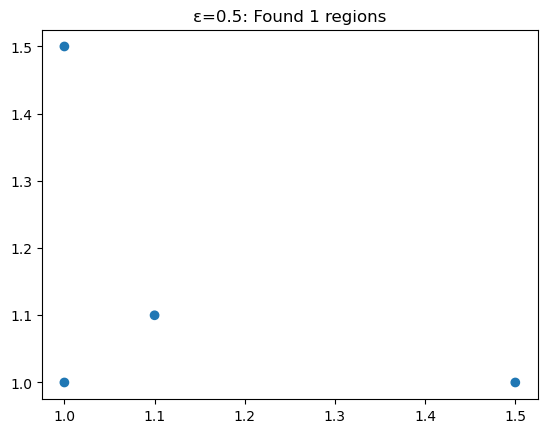

In [9]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
# Example with synthetic data
active_points = np.array([[1, 1], [1.5, 1], [1, 1.5], [1.1, 1.1]])
epsilon = 0.5

# Step 1: Build graph
nbrs = NearestNeighbors(radius=epsilon).fit(active_points)
adjacency = nbrs.radius_neighbors_graph(active_points, mode='connectivity')

# Step 2: Find regions
n_regions, labels = connected_components(adjacency)
print("Region labels:", labels)  # e.g., [0, 0, 1, 1]

# Visualize
plt.scatter(active_points[:, 0], active_points[:, 1], c=labels, cmap='tab10')
plt.title(f"ε={epsilon}: Found {n_regions} regions")
plt.show()

In [3]:
import numpy as np
lodata = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
epsilon = 0

In [4]:
laplace_noise = np.random.laplace(loc=0.0, scale=1/epsilon, size=lodata.shape)

ZeroDivisionError: division by zero

/var/folders/_y/0xw7_0ss0s3f4kfhj9xl96zw0000gn/T/ipykernel_51394/2226631686.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-paper')


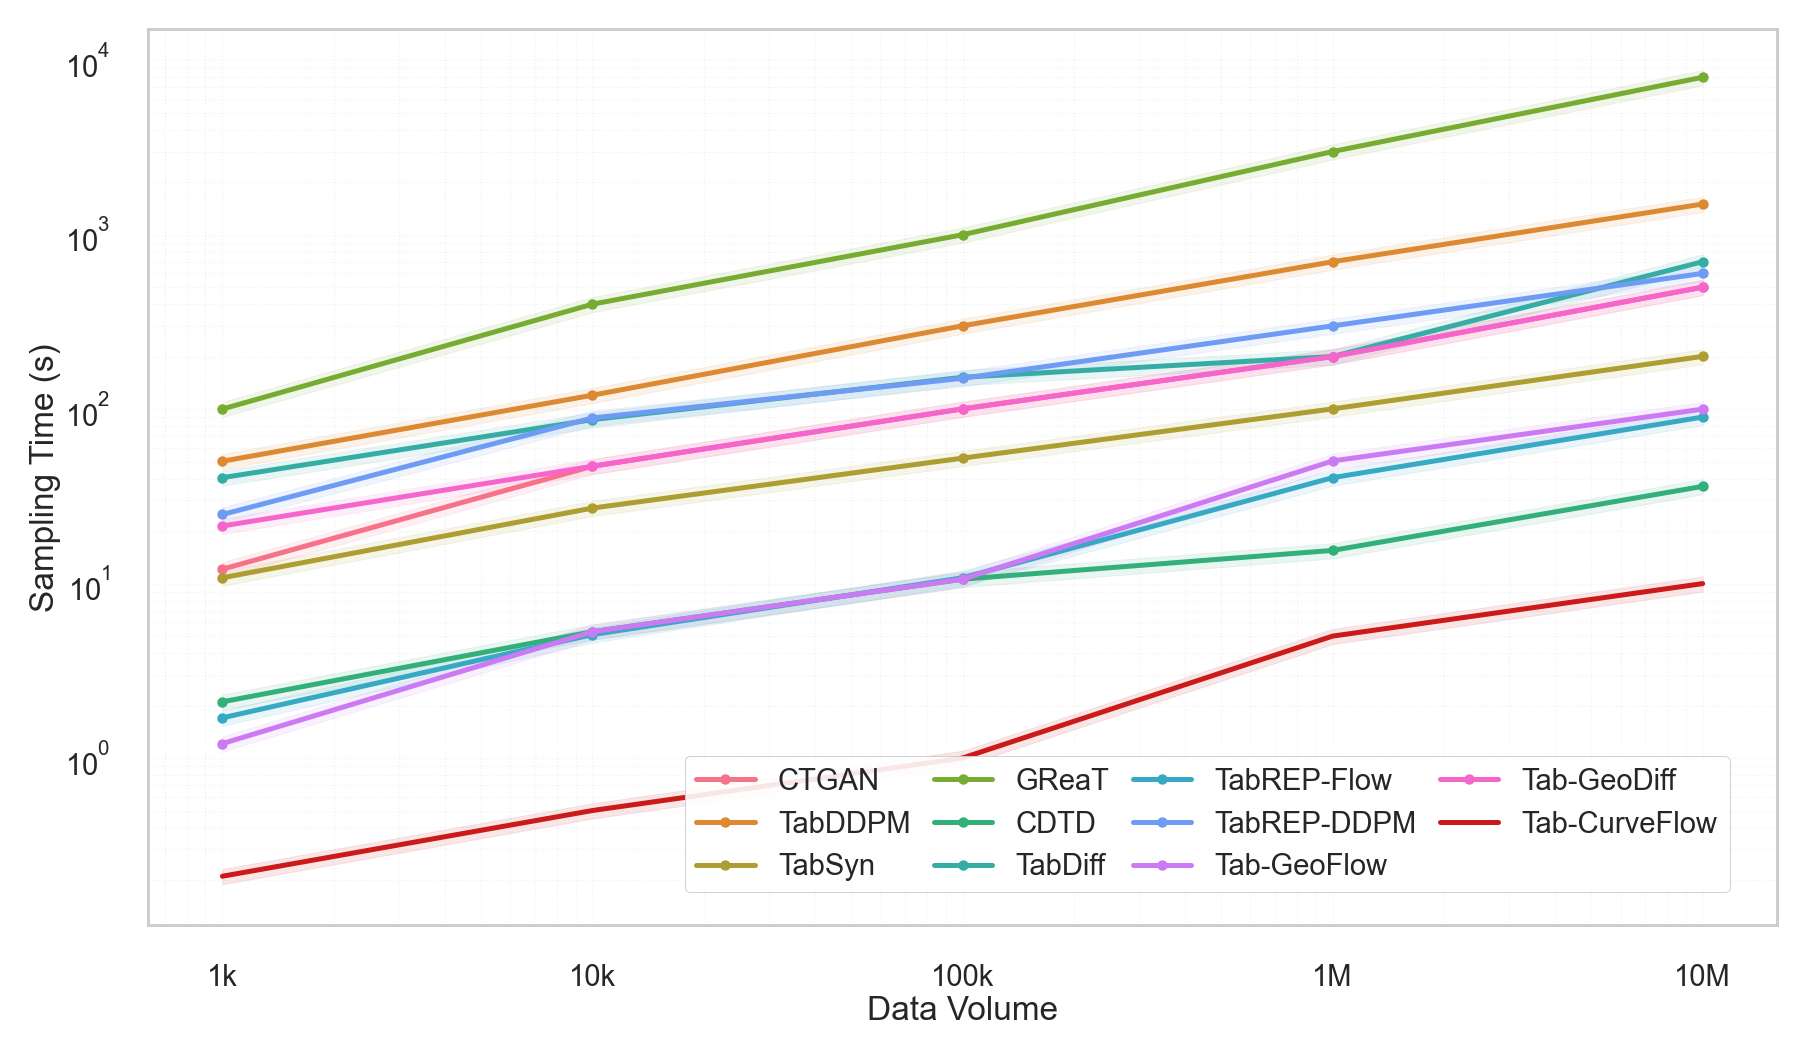

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import seaborn as sns

# Set NeurIPS-style formatting
plt.style.use('seaborn-paper')
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.7,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.2,
    'patch.edgecolor': 'none'
})

# Data volumes (1k, 10k, 100k, 1M, 10M)
data_volumes = [1e3, 1e4, 1e5, 1e6, 1e7]  

methods = {
    "CTGAN":          [12.1, 47.1, 100.4, 200.4, 500.5],
    "TabDDPM":        [50.3, 120.3, 300.6, 700.5, 1500.1],
    "TabSyn":         [10.8, 27.1, 52.4, 100.4, 200.8],
    "GReaT":          [100.2, 400.1, 1000.4,3000.4, 8000.5],
    "CDTD":           [2.1, 5.3, 10.6, 15.5, 36.1],
    "TabDiff":        [40.5, 87.1, 152.4, 200.4, 700.8],
    "TabREP-Flow":    [1.7, 5.1, 10.8, 40.5, 90.1],
    "TabREP-DDPM":    [24.9, 89.1, 150.4, 300.4, 600.5],
    "Tab-GeoFlow":    [1.21, 5.3, 10.6, 50.5, 100.1],
    "Tab-GeoDiff":    [21.4, 47.1, 100.4, 200.4, 500.8],
    "Tab-CurveFlow":  [0.21,  0.5, 1.0, 5.0, 10.0]  # Our method (highlighted)
}

errors = {k: [v*0.1 for v in vals] for k, vals in methods.items()}  # 10% error for demo

# Create figure
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

# Color palette (highlight our method in red)
palette = sns.color_palette("husl", n_colors=len(methods)-1) + [(0.8, 0.1, 0.1)]

# Plot all methods
for (method, vals), color in zip(methods.items(), palette):
    ax.plot(data_volumes, vals, color=color, label=method,
            marker='' if method == "Tab-CurveFlow" else '.',
            markersize=5)
    ax.fill_between(data_volumes, 
                    np.array(vals) - np.array(errors[method]),
                    np.array(vals) + np.array(errors[method]),
                    color=color, alpha=0.1)

# Axes formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(data_volumes)
ax.set_xticklabels(["1k", "10k", "100k", "1M", "10M"])
ax.set_xlabel("Data Volume", labelpad=1)
ax.set_ylabel("Sampling Time (s)", labelpad=1)
ax.grid(True, which="both", linestyle=":", linewidth=0.3, alpha=0.5)

# Legend in bottom right (4 columns to fit)
ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),  # Anchored to bottom-right corner
    ncol=4,
    columnspacing=0.8,
    frameon=True,
    framealpha=0.9,
    edgecolor='0.8'
)

plt.tight_layout(pad=0.8)
plt.savefig("sampling_time_neurips_bottomright.pdf", bbox_inches="tight", dpi=300)
plt.show()